# 08. Процессы восстановления

**Статус:** завершено

Процесс восстановления считает события, между которыми проходят независимые одинаково распределённые интервалы. Пуассоновский процесс — частный случай с экспоненциальными интервалами; в общем случае память уже появляется через возраст системы.

## Теория и интуиция

Пусть $T_1,T_2,\dots$ — интервалы между восстановлениями, а $S_n=T_1+\cdots+T_n$ — моменты восстановления. Тогда

$$N(t)=\max\{n:S_n\le t\}.$$

Если $\mu=\mathbb E[T_i]$, то по теореме восстановления при больших $t$

$$\mathbb E[N(t)]\approx \frac{t}{\mu}.

$$

Но распределение интервалов влияет на дисперсию, возраст и остаточное время. При экспоненциальных интервалах нет памяти; при гамма-интервалах события более регулярны; при логнормальных — появляются длинные паузы.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.renewal_processes import (
    calculate_age_and_residual_samples,
    calculate_empirical_renewal_mean_and_variance,
    plot_age_and_residual_distributions,
    plot_renewal_count_paths,
    plot_renewal_mean_functions,
    simulate_multiple_renewal_count_paths,
)

## 1. Три закона интервалов с одинаковым средним

,Модель интервалов,E[N(20)],Var[N(20)],E[age at 15],E[residual at 15]
0,экспоненциальные интервалы,20.0992,20.2022,0.9785,0.9499
1,гамма-интервалы,19.6088,4.9494,0.6310,0.6227
2,логнормальные интервалы,19.5936,5.7956,0.6500,0.6472


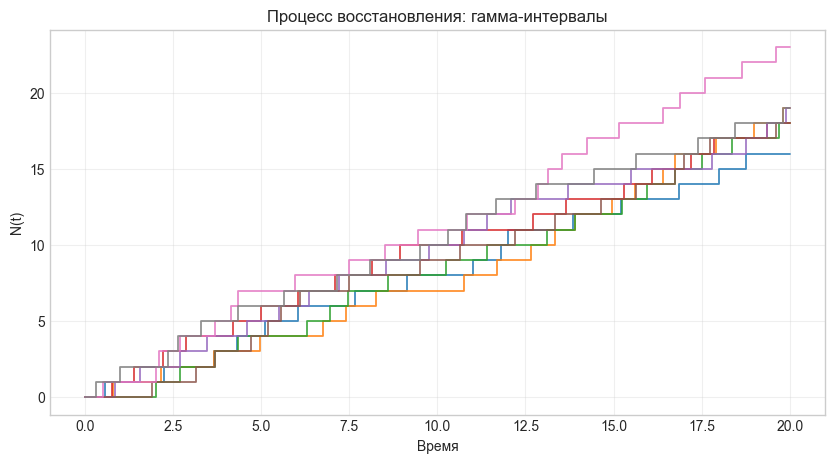

In [2]:
time_grid = np.linspace(0.0, 20.0, 401)
samplers = {
    "экспоненциальные интервалы": lambda rng, n: rng.exponential(scale=1.0, size=n),
    "гамма-интервалы": lambda rng, n: rng.gamma(shape=4.0, scale=0.25, size=n),
    "логнормальные интервалы": lambda rng, n: rng.lognormal(mean=-0.5 * 0.5**2, sigma=0.5, size=n),
}
renewal_results = {}
summary_rows = []
for name, sampler in samplers.items():
    event_times, count_paths = simulate_multiple_renewal_count_paths(2500, time_grid, sampler, random_seed=123)
    mean_count, variance_count = calculate_empirical_renewal_mean_and_variance(count_paths)
    ages, residuals = calculate_age_and_residual_samples(event_times, observation_time=15.0)
    renewal_results[name] = {"events": event_times, "counts": count_paths, "mean": mean_count, "var": variance_count, "ages": ages, "residuals": residuals}
    summary_rows.append({"Модель интервалов": name, "E[N(20)]": mean_count[-1], "Var[N(20)]": variance_count[-1], "E[age at 15]": np.mean(ages), "E[residual at 15]": np.nanmean(residuals)})

plot_renewal_count_paths(time_grid, renewal_results["гамма-интервалы"]["counts"], 8, "Процесс восстановления: гамма-интервалы");
pd.DataFrame(summary_rows)

У всех трёх моделей средний интервал примерно равен 1, поэтому $E[N(20)]$ находится около 20. Но дисперсия счёта сильно отличается: экспоненциальная модель дала `20.2022`, гамма — только `4.9494`, логнормальная — `5.7956`.

Интуитивно гамма-интервалы с shape=4 более регулярны, поэтому счёт к фиксированному времени меньше колеблется. Экспоненциальные интервалы гораздо шумнее, а логнормальные добавляют редкие длинные ожидания.

## 2. Функция восстановления

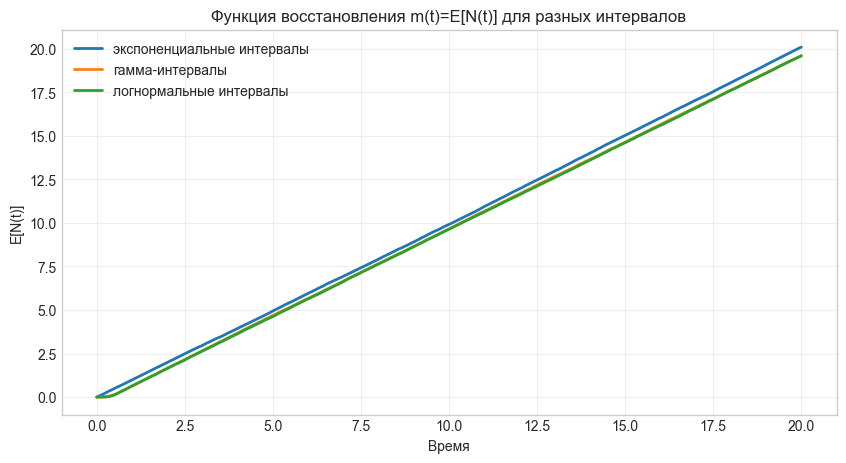

In [3]:
plot_renewal_mean_functions(
    time_grid=time_grid,
    mean_functions_by_name={name: values["mean"] for name, values in renewal_results.items()},
    title="Функция восстановления m(t)=E[N(t)] для разных интервалов",
);

Все кривые растут примерно линейно с наклоном $1/\mu\approx1$, но в начале отличаются. Это начальный эффект распределения первого интервала. Для практики это важно: асимптотика $t/\mu$ хороша на длинном горизонте, но на малых временах форма распределения интервалов заметна.

## 3. Возраст и остаточное время

,Модель интервалов,E[N(20)],Var[N(20)],E[age at 15],E[residual at 15]
0,экспоненциальные интервалы,20.0992,20.2022,0.9785,0.9499
1,гамма-интервалы,19.6088,4.9494,0.6310,0.6227
2,логнормальные интервалы,19.5936,5.7956,0.6500,0.6472


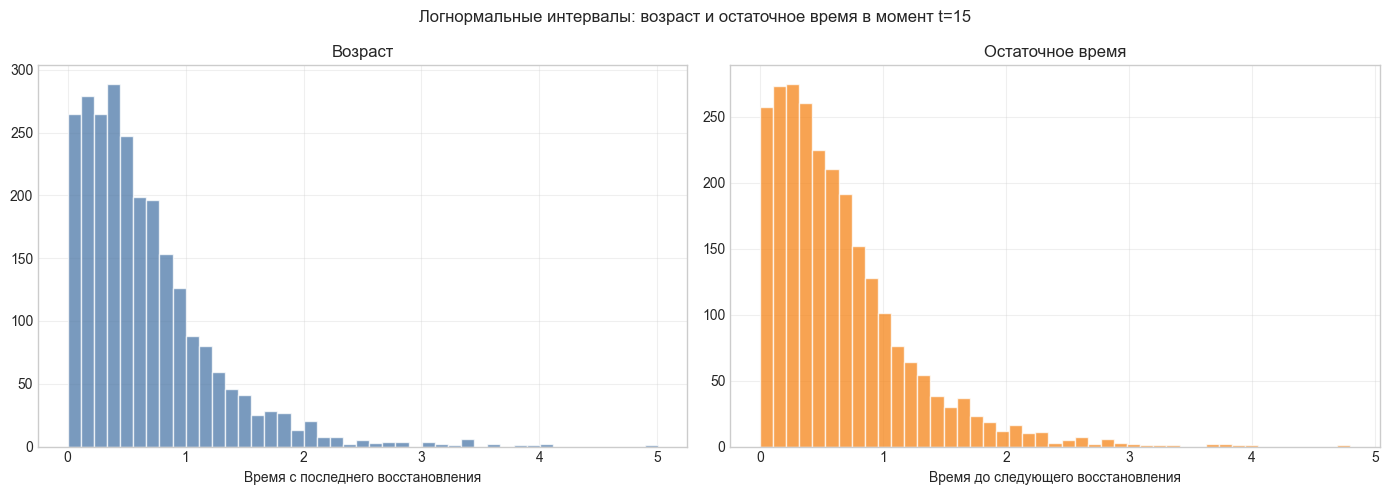

In [4]:
plot_age_and_residual_distributions(
    ages=renewal_results["логнормальные интервалы"]["ages"],
    residuals=renewal_results["логнормальные интервалы"]["residuals"],
    title="Логнормальные интервалы: возраст и остаточное время в момент t=15",
);

pd.DataFrame(summary_rows)

Возраст — время с последнего события, остаточное время — время до следующего. Для экспоненциальных интервалов средний возраст `0.9785` и среднее остаточное время `0.9499` близки к 1: это след отсутствия памяти.

Для гамма и логнормальной модели значения около `0.63–0.65`, потому что интервалы менее вариативны, и наблюдение в случайный момент чаще попадает ближе к середине более регулярного цикла. В более вариативных распределениях проявляется inspection paradox: случайный момент чаще попадает в длинный интервал.

## 4. Надёжность и запасные детали

In [5]:
spare_parts_needed = np.quantile(renewal_results["логнормальные интервалы"]["counts"][:, -1], 0.95)
pd.DataFrame({
    "Показатель": ["Среднее число замен за 20", "95%-квантиль числа замен", "Рекомендуемый запас для 95% сценариев"],
    "Значение": [renewal_results["логнормальные интервалы"]["mean"][-1], spare_parts_needed, np.ceil(spare_parts_needed)]
})

,Показатель,Значение
0,Среднее число замен за 20,19.5936
1,95%-квантиль числа замен,23.0000
2,Рекомендуемый запас для 95% сценариев,23.0000


Если восстановления — это замены деталей, то среднее число замен недостаточно для планирования склада. Для логнормальных интервалов среднее число замен около `19.5936`, но 95%-квантиль выше. Поэтому запас деталей лучше выбирать по квантилю, а не по среднему: среднее оптимистично для сервисного уровня.

## Выводы

1. Renewal-процесс обобщает пуассоновский процесс на произвольные интервалы между событиями.
2. При одинаковом среднем интервале разные распределения дают очень разную дисперсию счёта.
3. Функция восстановления асимптотически растёт как $t/\mu$, но начальное поведение зависит от закона интервалов.
4. Возраст и остаточное время показывают, что в общем renewal-процессе память есть.
5. Для задач надёжности и запасов важны квантили числа восстановлений, а не только среднее.